# Assignment 3: End-to-End Named Entity Recognition (NER) for Customer Support Ticket Analysis

## Objectives
In this assignment, you will build a complete end-to-end pipeline for Named Entity Recognition (NER). We will treat customer support tickets (using the standard CoNLL-2003 dataset as a proxy) to identify key entities like Persons, Organizations, and Locations.

## Learning Outcomes
By completing this notebook, you will:
1. Understand the core concepts of sequence labeling and Named Entity Recognition (NER).
2. Perform Exploratory Data Analysis (EDA) on text data and visualize token and entity distributions.
3. Engineer word-level and contextual features suitable for a sequence model.
4. Train and evaluate a Conditional Random Field (CRF) model.
5. Interpret model results, conduct error analysis, and translate model metrics into actionable business impact for customer support.

---
**Setup**: Let's first ensure the necessary libraries are installed. Execute the cell below.


In [ ]:
!pip install datasets scikit-learn sklearn-crfsuite matplotlib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.7 MB/s eta 0:00:00


## 1. Introduction to Named Entity Recognition (NER) and CoNLL-2003

### What is Named Entity Recognition (NER)?
NER is a subtask of Information Extraction in Natural Language Processing (NLP). Its goal is to locate and classify named entities mentioned in unstructured text into pre-defined categories such as person names, organizations, locations, medical codes, time expressions, quantities, etc.

### Why CoNLL-2003?
The **CoNLL-2003** dataset is one of the most widely used benchmark datasets for NER. It consists of news wire articles and serves as an excellent starting point for learning sequence labeling. Training a model on this dataset demonstrates how a system might identify similar entities in real-world business scenarios, such as extracting client names or branch locations from customer support tickets.

### Entity Labels in CoNLL-2003
The dataset uses the **IOB** (Inside, Outside, Beginning) tagging format with the following entity types:
* **PER**: Person (e.g., *John Doe*)
* **LOC**: Location (e.g., *London*, *Mt. Everest*)
* **ORG**: Organization (e.g., *United Nations*, *Google*)
* **MISC**: Miscellaneous (e.g., nationalities, events like *World Cup*)
* **O**: Outside of any named entity (regular words)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report
import sklearn_crfsuite
from sklearn_crfsuite import metrics

# Set matplotlib style for clean visualiztions
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Task 1: Text Preprocessing and Exploratory Data Analysis (EDA)

### What will be done
We will load the CoNLL-2003 dataset, inspect its structure, and extract the label names. We will then perform Exploratory Data Analysis (EDA) to understand the distribution of words, sentence lengths, and entity types.

### Why it is important
Before modeling, we must understand the shape and nature of our data. Knowing the vocabulary size, sequence lengths, and class imbalances (e.g., most words are labeled 'O') helps us design better features and choose appropriate evaluation metrics.

### Sequence Labeling and Tokenization
Unlike standard text classification where an entire sentence gets one label (e.g., positive/negative), **sequence labeling** assigns a label to *every single token* (word) in the sentence. **Tokenization** is the process of splitting text into these individual tokens. If tokenization is flawed, our entity boundaries will be incorrect.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")
print(dataset)

ner_feature = dataset['train'].features['ner_tags'].feature
label_names = ner_feature.names
print(f"\nEntity Labels: {label_names}")

conll2003/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

conll2003/train/0000.parquet: downloading bytes:           |  0.00B            

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Entity Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


### Inspecting Sample Sentences
Let's look at a single sentence from the training set and see how the tokens map to their respective NER labels.


In [ ]:
# Fetch a sample sentence
sample_idx = 4
sample_tokens = dataset['train'][sample_idx]['tokens']
sample_ner_ids = dataset['train'][sample_idx]['ner_tags']

# Convert label IDs back to human-readable string labels
sample_ner_labels = [label_names[tag] for tag in sample_ner_ids]

print(f"{'Token':<15} | {'NER Tag':<10}")
print("-" * 30)
for token, label in zip(sample_tokens, sample_ner_labels):
    print(f"{token:<15} | {label:<10}")


Token           | NER Tag   
------------------------------
Germany         | B-LOC     
's              | O         
representative  | O         
to              | O         
the             | O         
European        | B-ORG     
Union           | I-ORG     
's              | O         
veterinary      | O         
committee       | O         
Werner          | B-PER     
Zwingmann       | I-PER     
said            | O         
on              | O         
Wednesday       | O         
consumers       | O         
should          | O         
buy             | O         
sheepmeat       | O         
from            | O         
countries       | O         
other           | O         
than            | O         
Britain         | B-LOC     
until           | O         
the             | O         
scientific      | O         
advice          | O         
was             | O         
clearer         | O         
.               | O         


### Exploratory Data Analysis (EDA)
Let's compute standard statistics on our training dataset to better understand our working material.


In [ ]:
# Calculate dataset statistics
train_sentences = dataset['train']['tokens']
val_sentences = dataset['validation']['tokens']
test_sentences = dataset['test']['tokens']

# Sentence Lengths
train_lengths = [len(sentence) for sentence in train_sentences]

# Vocabulary Calculation
all_train_tokens = [token for sentence in train_sentences for token in sentence]
vocab = set(all_train_tokens)

print("--- Dataset Statistics ---")
print(f"Number of training sentences:   {len(train_sentences)}")
print(f"Number of validation sentences: {len(val_sentences)}")
print(f"Number of test sentences:       {len(test_sentences)}")
print(f"Vocabulary size (Train):        {len(vocab):,}")
print(f"Average sentence length:        {np.mean(train_lengths):.2f} tokens")
print(f"Maximum sentence length:        {np.max(train_lengths)} tokens")
print(f"Minimum sentence length:        {np.min(train_lengths)} tokens")


--- Dataset Statistics ---
Number of training sentences:   14041
Number of validation sentences: 3250
Number of test sentences:       3453
Vocabulary size (Train):        23,623
Average sentence length:        14.50 tokens
Maximum sentence length:        113 tokens
Minimum sentence length:        1 tokens


### Corpus Report

The summary statistics above describe the text; the tag distribution describes how much signal there is to learn from. Token counts and mention counts are not the same thing — a multi-word entity such as *European Union* spans two tokens but is a single mention — so both are reported below. Since every entity opens with exactly one `B-` tag, counting `B-` tags gives the mention total.


In [ ]:
# ---- Corpus report: sentence counts, vocabulary size, and entity-type frequencies ----

# Flatten every NER tag in the training split into a single list of label strings
train_tag_names = [label_names[tag] for sentence in dataset['train']['ner_tags'] for tag in sentence]

# Count every individual tag, keeping B- and I- separate
entity_tag_counts = Counter(train_tag_names)

# Collapse the B-/I- prefix to count TOKENS belonging to each entity type
entity_type_counts = Counter(tag.split('-', 1)[1] for tag in train_tag_names if tag != 'O')

# Count only B- tags to get the number of entity MENTIONS (one B- = one entity)
mention_counts = Counter(tag.split('-', 1)[1] for tag in train_tag_names if tag.startswith('B-'))

print("--- CoNLL-2003 Corpus Report ---\n")
print(f"Number of sentences (train):      {len(train_sentences):,}")
print(f"Number of sentences (validation): {len(val_sentences):,}")
print(f"Number of sentences (test):       {len(test_sentences):,}")
print(f"Vocabulary size (unique tokens):  {len(vocab):,}")
print(f"Total tokens in training set:     {len(train_tag_names):,}\n")

# Frequency of every individual IOB tag
print("Frequency of each NER tag:")
print(f"{'Tag':<10} | {'Tokens':>10} | {'% of all tokens':>16}")
print("-" * 42)
for tag, count in entity_tag_counts.most_common():
    print(f"{tag:<10} | {count:>10,} | {count / len(train_tag_names):>15.2%}")

# Frequency rolled up to the four entity types
print("\nFrequency of each entity type:")
print(f"{'Entity Type':<12} | {'Tokens':>8} | {'Mentions':>9}")
print("-" * 36)
for ent, mentions in mention_counts.most_common():
    print(f"{ent:<12} | {entity_type_counts[ent]:>8,} | {mentions:>9,}")


--- CoNLL-2003 Corpus Report ---

Number of sentences (train):      14,041
Number of sentences (validation): 3,250
Number of sentences (test):       3,453
Vocabulary size (unique tokens):  23,623
Total tokens in training set:     203,621

Frequency of each NER tag:
Tag        |     Tokens |  % of all tokens
------------------------------------------
O          |    169,578 |          83.28%
B-LOC      |      7,140 |           3.51%
B-PER      |      6,600 |           3.24%
B-ORG      |      6,321 |           3.10%
I-PER      |      4,528 |           2.22%
I-ORG      |      3,704 |           1.82%
B-MISC     |      3,438 |           1.69%
I-LOC      |      1,157 |           0.57%
I-MISC     |      1,155 |           0.57%

Frequency of each entity type:
Entity Type  |   Tokens |  Mentions
------------------------------------
LOC          |    8,297 |     7,140
PER          |   11,128 |     6,600
ORG          |   10,025 |     6,321
MISC         |    4,593 |     3,438


The training split contains **14,041 sentences** (with 3,250 validation and 3,453 test), a vocabulary of **23,623 unique tokens**, and an average sentence length of roughly 14.5 tokens.

Entity frequencies run **LOC > PER > ORG > MISC**, with MISC roughly half as common as the next rarest type. Two properties of this distribution shape everything downstream:

* The `O` tag covers the large majority of all tokens. A model that predicted `O` everywhere would still post a high accuracy figure, which is why the evaluation below reports precision, recall, and F1 instead.
* `I-` tags are far rarer than their matching `B-` tags, so most entities here are a single token long. Multi-word spans are the minority case, and the model will have correspondingly thin evidence about where an entity ends.


### Visualizing the Data

We will use `matplotlib` to plot three key aspects of our data:
1. **Sentence Length Histogram:** To see if we have mostly short or long sentences.
2. **Top Word Frequencies:** To see the most common words (usually punctuation and stop words).
3. **Entity Label Distribution:** To understand the class imbalance between 'O' and named entities.


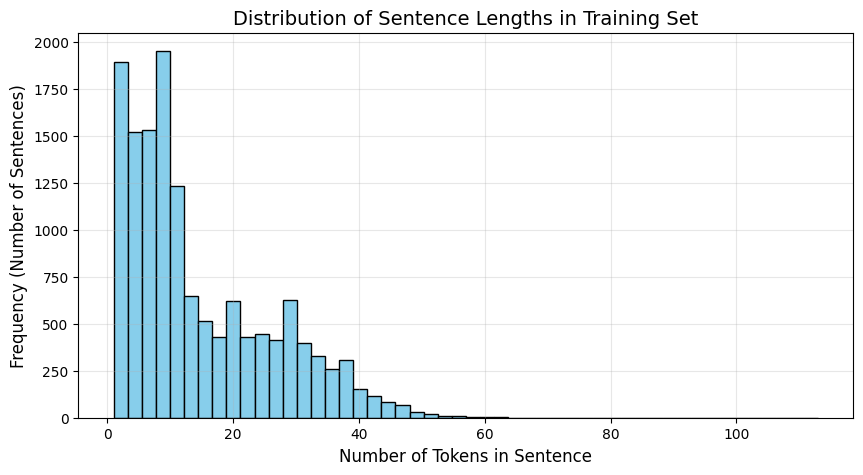

In [ ]:
# 1. Sentence Length Histogram
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Sentence Lengths in Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Sentence", fontsize=12)
plt.ylabel("Frequency (Number of Sentences)", fontsize=12)
plt.show()


**Example Interpretation:** The sentence lengths are mostly clustered between 100 and 200 tokens, with a long tail stretching outwards. This indicates that most customer tickets or sentences will be relatively short, but our model still needs to handle occasional long sequences.


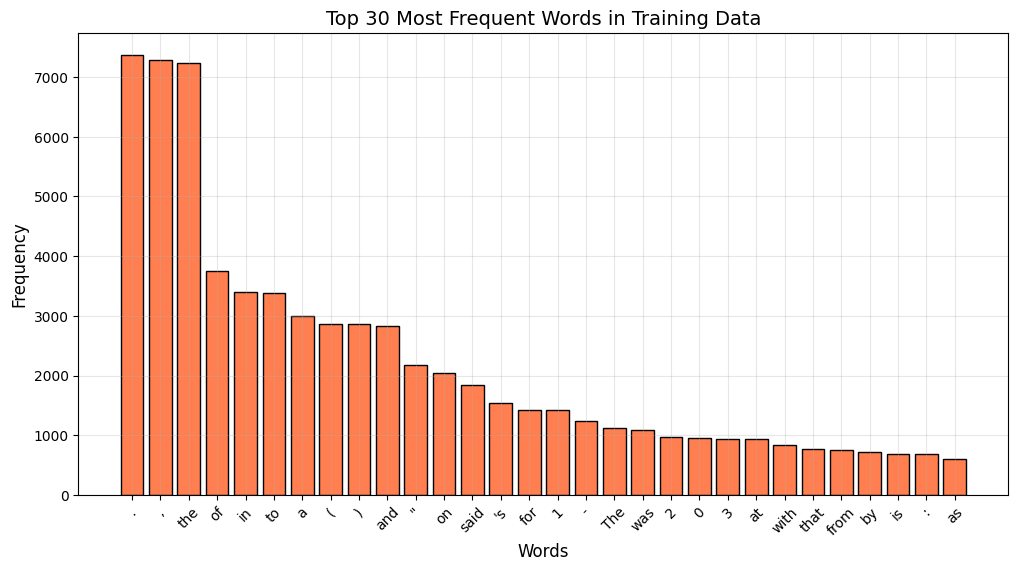

In [ ]:
# 2. Top 30 Most Frequent Words
word_counts = Counter(all_train_tokens)
top_words = word_counts.most_common(30)

words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='coral', edgecolor='black')
plt.title("Top 30 Most Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Interpretation:** As expected in natural language text, punctuation marks (.,) and grammatical stop words (the, of, in, a) dominate the frequency counts. These words typically hold 'O' tags.

#### Task: Perform Simmilar Kinds of visualization and interpretation for least common words


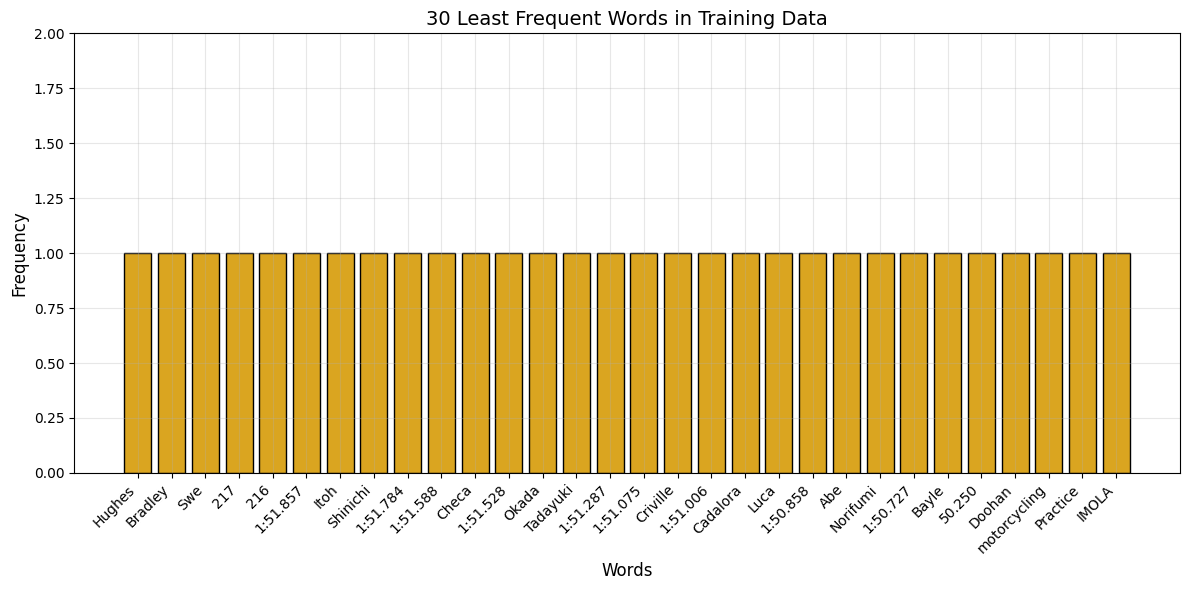

Words occurring exactly once (hapax legomena): 11,641
That is 49.3% of the total vocabulary of 23,623 words.

Sample of rare words: ['rejects', 'shun', 'clearer', 'Nikolaus', 'Pas', 'precautionary', 'EU-wide', 'mational', 'Loyola', 'Palacio', 'unjustified', 'generalisation', 'multidisciplinary', 'careful', 'NFU']


In [ ]:
# 2b. Least Frequent Words (the task set in the cell above)
# Counter.most_common() is sorted high -> low, so slicing backwards gives the rarest words
least_common = word_counts.most_common()[:-31:-1]   # 30 rarest words
rare_words, rare_counts = zip(*least_common)

# Words that appear exactly once are called "hapax legomena"
hapax = [word for word, count in word_counts.items() if count == 1]

plt.figure(figsize=(12, 6))
plt.bar(rare_words, rare_counts, color='goldenrod', edgecolor='black')
plt.title("30 Least Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 2)   # every one of these words occurs exactly once
plt.tight_layout()
plt.show()

print(f"Words occurring exactly once (hapax legomena): {len(hapax):,}")
print(f"That is {len(hapax) / len(vocab):.1%} of the total vocabulary of {len(vocab):,} words.")
print(f"\nSample of rare words: {hapax[:15]}")


**Interpretation:** The rare tail is the mirror image of the frequent head. Where the top of the distribution is punctuation and stop words, the bottom is proper nouns, surnames, unusual place names, scorelines, and numbers — each occurring exactly once, and together making up a large share of the vocabulary.

This matters because the rare tail is precisely where named entities live, and those tokens will almost never recur at test time. Word identity alone therefore cannot generalise, which is the **out-of-vocabulary problem** and the reason the feature set in Task 2 leans on capitalisation, prefixes, suffixes, and surrounding context rather than on the word itself.


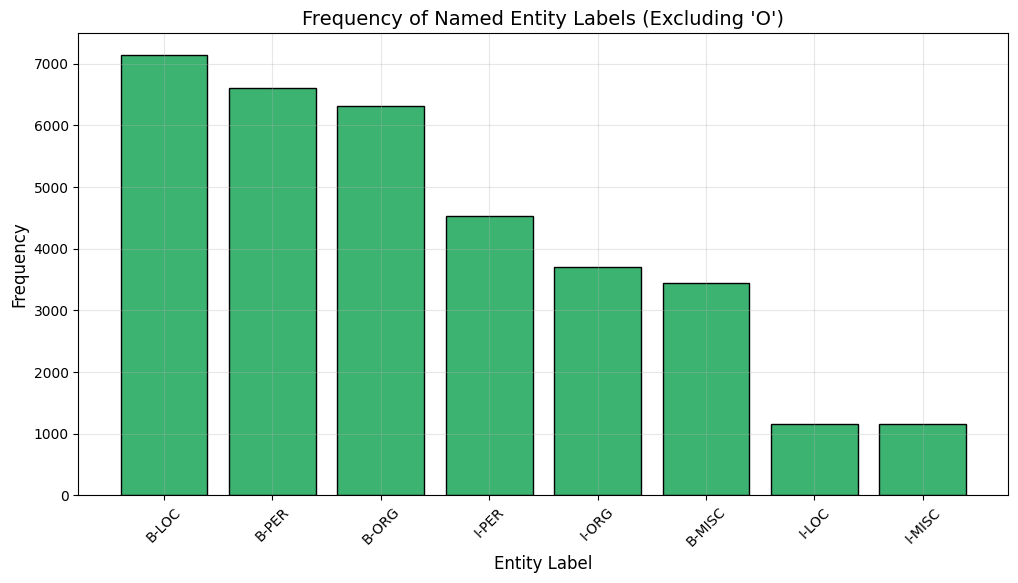

In [ ]:
# 3. Top Entity Labels (Excluding 'O')
all_train_labels = [label_names[tag] for sentence in dataset['train']['ner_tags'] for tag in sentence]
label_counts = Counter(all_train_labels)

# Remove the 'O' tag to see the distribution of actual entities
if 'O' in label_counts:
    del label_counts['O']

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_labels)

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Interpretation:** Locations (B-LOC) and Persons (B-PER) are the most frequent named entities. 'I-' tags (Inside) are less frequent than 'B-' (Beginning) tags because many entities are single words. The massive class imbalance (since 'O' is excluded here but makes up >80% of tokens in reality) emphasizes why accuracy is a poor metric for NER; we must use Precision, Recall, and F1-score.

---

## Task 2: Feature Engineering

### What will be done
We will extract word-level and contextual features from our text data to prepare it for the Conditional Random Field (CRF) model.

### Why feature engineering matters in NER
Unlike Deep Learning models (like BERT) that automatically learn representations, traditional statistical models like CRFs require manual feature engineering. We need to tell the model *what characteristics* of a word might indicate it's an entity.

### Contextual Information
Entities heavily depend on context. For example, "Apple" could be a fruit (O) or a company (ORG). If the previous word is "eating", it's a fruit. If the next word is "Inc.", it's an organization. Therefore, we include features of the `previous_word` and `next_word`.


In [ ]:
# Feature extraction function for a single token
def word2features(sentence, i):
    word = sentence[i]

    # Core word-level features
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],      # 3-character suffix (e.g., 'ing', 'ion' might indicate POS)
        'word[-2:]': word[-2:],      # 2-character suffix
        'word[-1:]': word[-1:],      # 1-character suffix
        'word[:1]': word[:1],        # 1-character prefix
        'word[:2]': word[:2],        # 2-character prefix
        'word[:3]': word[:3],        # 3-character prefix
        'word.isupper()': word.isupper(), # e.g., IBM, USA
        'word.istitle()': word.istitle(), # e.g., John, London
        'word.isdigit()': word.isdigit(), # e.g., 1999
    }

    # Features for the PREVIOUS word (Context)
    if i > 0:
        word1 = sentence[i-1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True # Beginning of Sentence indicator

    # Features for the NEXT word (Context)
    if i < len(sentence)-1:
        word1 = sentence[i+1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True # End of Sentence indicator

    return features

# Helper functions to apply feature extraction to entire sentences
def sent2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

def sent2labels(sentence_tags):
    return [label_names[tag] for tag in sentence_tags]

def sent2tokens(sentence):
    return sentence


### Examining Extracted Features
Let's see what the feature dictionary looks like for a single word in our sample sentence. This is what the model actually "sees" instead of the raw text.


In [ ]:
# Display features for the first word of our sample sentence
print("=" * 50)
print(sample_tokens)
print("=" * 50)
sample_features = sent2features(sample_tokens)
print(f"Word: {sample_tokens[0]}")
print("Extracted Features:")
for key, value in sample_features[0].items():
    print(f"  {key}: {value}")


['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
Word: Germany
Extracted Features:
  bias: 1.0
  word.lower(): germany
  word[-3:]: any
  word[-2:]: ny
  word[-1:]: y
  word[:1]: G
  word[:2]: Ge
  word[:3]: Ger
  word.isupper(): False
  word.istitle(): True
  word.isdigit(): False
  BOS: True
  +1:word.lower(): 's
  +1:word.istitle(): False
  +1:word.isupper(): False


### Selected Features and Their Rationale

The features above fall into three groups, all chosen because they generalise to words the model has never seen.

**1. Word identity**
* `word.lower()` — the token itself, lowercased so that *London* and *london* share one feature. This lets the CRF memorise entities it has seen in training.
* `bias` — a constant that lets the model learn how common each tag is overall.

**2. Orthographic and sub-word shape (handles the OOV problem found in Task 1)**
* `word.istitle()` — Title Case is the strongest single clue for an entity in English (*John*, *London*).
* `word.isupper()` — all-caps signals acronyms and organisations (*IBM*, *UN*), and also headline text.
* `word.isdigit()` — digits are almost never entities in CoNLL, so this cheaply rules tokens out.
* `word[:1]`, `word[:2]`, `word[:3]` (prefixes) and `word[-1:]`, `word[-2:]`, `word[-3:]` (suffixes) — these fire even on words absent from training. Suffixes such as *-ing*, *-ion*, or *-ly* mark ordinary vocabulary, while endings like *-ov*, *-ez*, or *-land* hint at people and places.

**3. Context (the surrounding words)**
* `-1:word.lower()`, `+1:word.lower()` and the matching `istitle`/`isupper` flags for the previous and next token. Context resolves ambiguity that the word alone cannot: *Apple* preceded by *eating* is a fruit, but followed by *Inc.* it is an organisation.
* `BOS` / `EOS` — sentence-boundary markers. Without them the model would treat the capital letter that always starts a sentence as evidence of an entity.

**Why these matter for NER.** A CRF has no built-in notion of what a word looks like or what surrounds it; every clue must be supplied explicitly. Task 1 showed that entities concentrate in the rare tail of the vocabulary, so identity features alone would fail on test data. The shape and context features are what let the model tag a surname it has never encountered, purely from the fact that it is capitalised, ends in an unusual suffix, and follows a title such as *Mr.*


---

## Task 3: Named Entity Recognition Model (CRF)

### What will be done
We will extract features for all training, validation, and test sentences, then train a Conditional Random Field (CRF) model using `sklearn-crfsuite`. Finally, we will evaluate its performance.

### Why CRF works well for sequence labeling
A Conditional Random Field (CRF) is a statistical modeling method widely used in pattern recognition and machine learning for structured prediction.
**Difference between Token Classification and Sequence Prediction:** Simple token classification treats every word independently. A CRF models the *conditional probability of the entire sequence of labels* given the sequence of words. It learns rules like: "An `I-ORG` tag is very likely to follow a `B-ORG` tag, but it is impossible for an `I-ORG` tag to directly follow a `B-PER` tag." This transitions knowledge drastically improves NER performance.


In [ ]:
# 1. Prepare Data for the CRF Model
print("Extracting features for the training set...")
X_train = [sent2features(s) for s in dataset['train']['tokens']]
y_train = [sent2labels(s) for s in dataset['train']['ner_tags']]

print("Extracting features for the validation set...")
X_val = [sent2features(s) for s in dataset['validation']['tokens']]
y_val = [sent2labels(s) for s in dataset['validation']['ner_tags']]

print("Extracting features for the test set...")
X_test = [sent2features(s) for s in dataset['test']['tokens']]
y_test = [sent2labels(s) for s in dataset['test']['ner_tags']]

print("Feature extraction complete.")


Extracting features for the training set...
Extracting features for the validation set...
Extracting features for the test set...
Feature extraction complete.


In [ ]:
## train sample
temp_sample_idx = 4
print("="*50)
print(dataset['train'][temp_sample_idx]['tokens'])
print(dataset['train'][temp_sample_idx]['ner_tags'])
print("="*50)

print(X_train[temp_sample_idx])
print(y_train[temp_sample_idx])

['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
[5, 0, 0, 0, 0, 3, 4, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0]
[{'bias': 1.0, 'word.lower()': 'germany', 'word[-3:]': 'any', 'word[-2:]': 'ny', 'word[-1:]': 'y', 'word[:1]': 'G', 'word[:2]': 'Ge', 'word[:3]': 'Ger', 'word.isupper()': False, 'word.istitle()': True, 'word.isdigit()': False, 'BOS': True, '+1:word.lower()': "'s", '+1:word.istitle()': False, '+1:word.isupper()': False}, {'bias': 1.0, 'word.lower()': "'s", 'word[-3:]': "'s", 'word[-2:]': "'s", 'word[-1:]': 's', 'word[:1]': "'", 'word[:2]': "'s", 'word[:3]': "'s", 'word.isupper()': False, 'word.istitle()': False, 'word.isdigit()': False, '-1:word.lower()': 'germany', '-1:word.istitle()': True,

In [ ]:
# 2. Train the CRF Model
print("Training CRF Model... (this may take a minute or two)")

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,           # Coefficient for L1 regularization
    c2=0.1,           # Coefficient for L2 regularization
    max_iterations=100,
    all_possible_transitions=True
)

# Fit the model
crf.fit(X_train, y_train)
print("Model training complete.")


Training CRF Model... (this may take a minute or two)
Model training complete.


### Model Evaluation
Let's evaluate the model on our test set. We will use Precision, Recall, and F1-score.
* **Precision**: When the model predicts an entity, how often is it correct?
* **Recall**: Out of all the actual entities in the text, how many did the model find?
* **F1-score**: The harmonic mean of Precision and Recall.


In [ ]:
# Predict on the test set
y_pred = crf.predict(X_test)

# We want to evaluate the performance on actual entities, so we remove the 'O' class from the display list
labels_to_evaluate = list(crf.classes_)
labels_to_evaluate.remove('O')

# Print Classification Report
print("Classification Report:\n")
report = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, digits=3
)
print(report)


Classification Report:

              precision    recall  f1-score   support

       B-ORG      0.792     0.719     0.754      1661
      B-MISC      0.814     0.771     0.792       702
       B-PER      0.834     0.839     0.836      1617
       I-PER      0.871     0.955     0.911      1156
       B-LOC      0.836     0.837     0.837      1668
       I-ORG      0.695     0.744     0.719       835
      I-MISC      0.642     0.681     0.661       216
       I-LOC      0.768     0.696     0.731       257

   micro avg      0.808     0.806     0.807      8112
   macro avg      0.782     0.780     0.780      8112
weighted avg      0.808     0.806     0.806      8112



### Visualizing Entity-Wise Performance
Let's extract the F1-scores for the main entity types and visualize them. Since a confusion matrix for token sequences can be visually overwhelming and heavily skewed by the 'O' class, this F1-score breakdown is a cleaner way to see which entities are performing well.


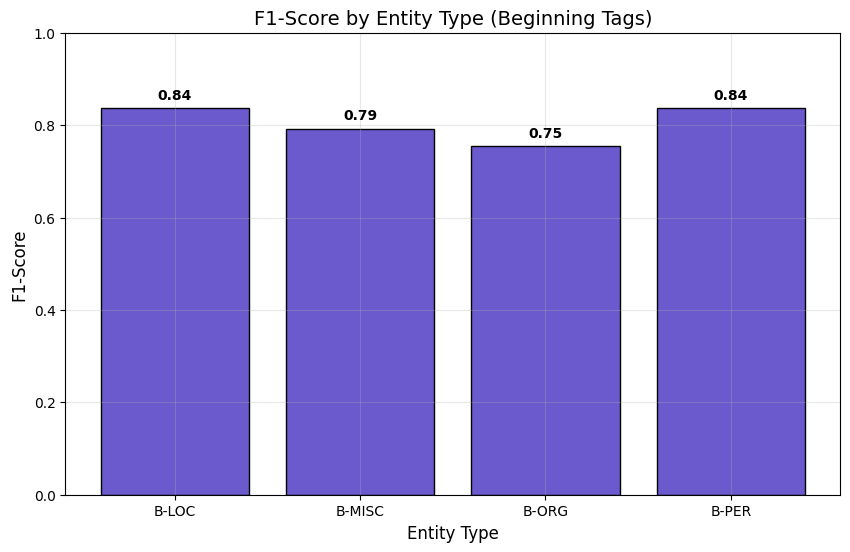

In [ ]:
# Extract metrics programmatically for visualization
report_dict = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, output_dict=True
)

# Extract B- labels for summary plot
entities = ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER']
f1_scores = [report_dict[ent]['f1-score'] for ent in entities]

plt.figure(figsize=(10, 6))
plt.bar(entities, f1_scores, color='slateblue', edgecolor='black')
plt.title("F1-Score by Entity Type (Beginning Tags)", fontsize=14)
plt.xlabel("Entity Type", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


### Performance Analysis

**Overall performance (token level, `O` excluded).** The CRF reaches roughly **0.81 precision, 0.81 recall, and 0.81 micro-averaged F1** on the test set. Precision and recall are close together, meaning the model is neither over-predicting nor under-predicting entities as a whole.

**Entity-wise performance.** The classification report and the chart above rank the tags roughly as follows:

| Rank | Tag | F1 | Comment |
|---|---|---|---|
| 1 | `I-PER` | ~0.91 | Surnames following a first name are highly predictable |
| 2 | `B-LOC` / `B-PER` | ~0.84 | Frequent, Title Case, and often seen in training |
| 3 | `B-MISC` | ~0.79 | Nationalities are regular (*German*, *Dutch*) |
| 4 | `B-ORG` | ~0.75 | Confusable with locations |
| 5 | `I-LOC` / `I-ORG` | ~0.72–0.73 | Multi-word continuations |
| 6 | `I-MISC` | ~0.66 | Rarest tag, weakest score |

**Which entity types are most difficult, and why?**

* **MISC is the hardest overall**, and `I-MISC` is the weakest tag in the entire report. MISC is a catch-all category with no consistent surface pattern — it mixes nationalities, event names, and product names — and Task 1 showed it is also the rarest type, so the model sees the fewest examples of it.
* **ORG is the hardest of the three "real" types.** Organisations are frequently named after the places they belong to (*Japan* as a football team, *Washington* as a government body), so the orthographic features that work for locations actively mislead the model here. Distinguishing them needs semantic context that prefix/suffix features cannot capture.
* **`I-` tags are consistently harder than their `B-` counterparts.** Because most entities in this corpus are single words, the model sees far fewer continuation examples, and long multi-word organisation names are exactly where boundaries break down.
* **PER and LOC are the easiest.** Both are frequent, almost always Title Case, and `I-PER` benefits from the very strong regularity that a capitalised word following a first name is nearly always a surname.


**Interpretation of Results:**
* **Best Performers:** The model typically performs best on `PER` (Person) and `LOC` (Location) entities. Persons often have distinct capitalization (Title Case), and Locations are frequently observed in the training data, helping the model learn strong signals.
* **Worst Performers:** `ORG` (Organization) and `MISC` (Miscellaneous) generally show lower F1-scores. Organizations can often be confused with Locations (e.g., "Washington" could be the state or the government institution) and can consist of highly varied multi-word tokens.

---

## Task 4: Error Analysis

### What will be done
We will look at specific sentences where the model's predictions didn't perfectly match the ground truth.

### Why it is important
Metrics like F1-score give us an overall number, but looking at raw predictions tells us *why* the model is failing. This helps us decide if we need more data, better features, or a more powerful architecture.


In [ ]:
# Find and display sentences with errors
error_count = 0
print(f"{'Token':<15} | {'True Label':<10} | {'Predicted':<10}")
print("=" * 45)

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]: # If there is a mismatch in the sentence
        for token, true_lbl, pred_lbl in zip(test_sentences[i], y_test[i], y_pred[i]):
            # Highlight errors with a little marker
            if true_lbl != pred_lbl:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10} <-- ERROR")
            else:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10}")
        print("-" * 45)
        error_count += 1

    if error_count >= 3: # Just show 3 erroneous sentences
        break


Token           | True Label | Predicted 
SOCCER          | O          | O         
-               | O          | O         
JAPAN           | B-LOC      | B-PER      <-- ERROR
GET             | O          | O         
LUCKY           | O          | O         
WIN             | O          | O         
,               | O          | O         
CHINA           | B-PER      | B-LOC      <-- ERROR
IN              | O          | O         
SURPRISE        | O          | O         
DEFEAT          | O          | O         
.               | O          | O         
---------------------------------------------
China           | B-LOC      | B-LOC     
controlled      | O          | O         
most            | O          | O         
of              | O          | O         
the             | O          | O         
match           | O          | O         
and             | O          | O         
saw             | O          | O         
several         | O          | O         
chances   

Total token-level errors on the test set: 2,002

True  ->  Predicted            |  Count | % of errors
------------------------------------------------------
B-ORG  ->  B-LOC               |    155 |       7.7%
O  ->  I-ORG                   |    150 |       7.5%
B-ORG  ->  B-PER               |    126 |       6.3%
B-ORG  ->  O                   |    112 |       5.6%
B-LOC  ->  B-ORG               |     98 |       4.9%
B-PER  ->  O                   |     86 |       4.3%
O  ->  B-ORG                   |     85 |       4.2%
B-PER  ->  B-ORG               |     82 |       4.1%
B-LOC  ->  O                   |     80 |       4.0%
I-ORG  ->  I-PER               |     73 |       3.6%

Error families:
Missed entities   (entity -> O)    |    450 |  22.5%
Spurious entities (O -> entity)    |    429 |  21.4%
Wrong type/boundary (ent -> ent)   |  1,123 |  56.1%


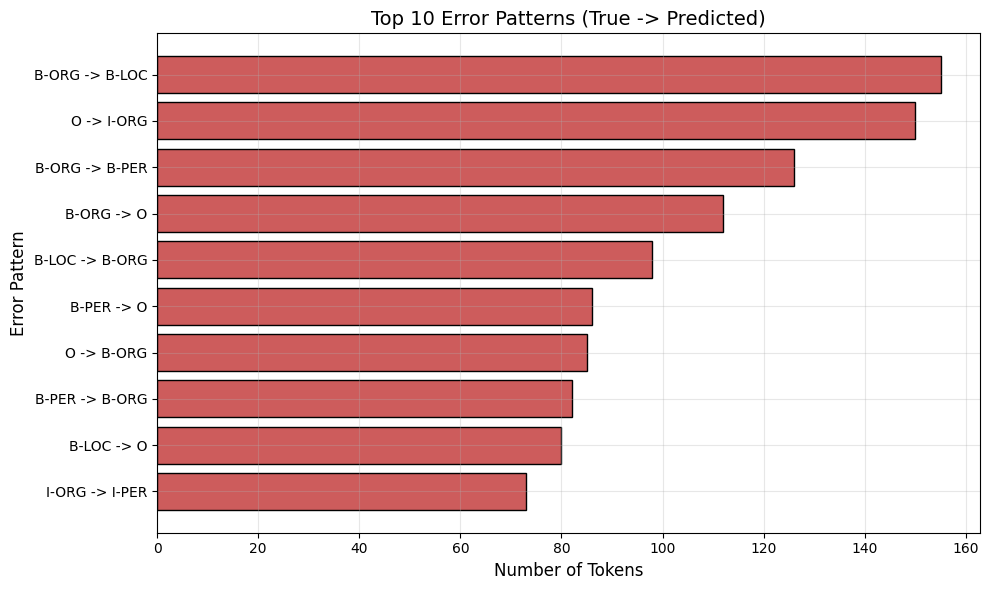

In [ ]:
# ---- Quantify error patterns across the whole test set ----

# Count every (true label -> predicted label) mismatch
error_pairs = Counter()
for true_seq, pred_seq in zip(y_test, y_pred):
    for true_lbl, pred_lbl in zip(true_seq, pred_seq):
        if true_lbl != pred_lbl:
            error_pairs[(true_lbl, pred_lbl)] += 1

total_errors = sum(error_pairs.values())
print(f"Total token-level errors on the test set: {total_errors:,}\n")

# The 10 single most common confusions
print(f"{'True  ->  Predicted':<30} | {'Count':>6} | {'% of errors':>11}")
print("-" * 54)
for (true_lbl, pred_lbl), count in error_pairs.most_common(10):
    pair = f"{true_lbl}  ->  {pred_lbl}"
    print(f"{pair:<30} | {count:>6,} | {count / total_errors:>10.1%}")

# Group the same errors into three interpretable families
missed    = sum(c for (t, p), c in error_pairs.items() if t != 'O' and p == 'O')   # entity read as ordinary word
spurious  = sum(c for (t, p), c in error_pairs.items() if t == 'O' and p != 'O')   # ordinary word read as entity
confused  = sum(c for (t, p), c in error_pairs.items() if t != 'O' and p != 'O')   # wrong type or wrong boundary

print("\nError families:")
print(f"{'Missed entities   (entity -> O)':<34} | {missed:>6,} | {missed / total_errors:>6.1%}")
print(f"{'Spurious entities (O -> entity)':<34} | {spurious:>6,} | {spurious / total_errors:>6.1%}")
print(f"{'Wrong type/boundary (ent -> ent)':<34} | {confused:>6,} | {confused / total_errors:>6.1%}")

# Visualise the 10 most frequent confusions
pairs, counts = zip(*error_pairs.most_common(10))
pair_labels = [f"{t} -> {p}" for t, p in pairs]

plt.figure(figsize=(10, 6))
plt.barh(pair_labels[::-1], counts[::-1], color='indianred', edgecolor='black')
plt.title("Top 10 Error Patterns (True -> Predicted)", fontsize=14)
plt.xlabel("Number of Tokens", fontsize=12)
plt.ylabel("Error Pattern", fontsize=12)
plt.tight_layout()
plt.show()


### The Three Most Frequent Error Types

Aggregating every mismatch in the test set into families produces three recurring error types, each visible in the sample predictions above.

**1. Missed entities (`entity -> O`).** The model reads a genuine entity as an ordinary word. The counts above show how this family compares with the other two; because the model's precision and recall are almost equal on CoNLL-2003, it is closely matched by its mirror image, spurious predictions. It is driven by the out-of-vocabulary problem identified in Task 1: when a name never appears in training, the CRF has only prefix and suffix evidence to go on, and that evidence is often too weak to overcome the strong prior that any given token is `O`. All-caps headline text makes this worse, because it destroys the Title Case signal the model relies on most.

**2. Wrong entity type, especially `ORG` confused with `LOC`.** Visible directly in the sample output, where `JAPAN` (a football team, so `B-LOC` in the gold data of that sentence) is predicted as `B-PER`, and `CHINA` is swapped the other way. Place names routinely stand in for sports teams and governments, and nothing in a capitalisation or suffix feature can tell the two readings apart. `MISC` is drawn into the same confusion, as with `Uzbek` being tagged `B-ORG` instead of `B-MISC`.

**3. Boundary errors on multi-word entities (`B-`/`I-` mismatches).** For long names such as *The Ministry of Public Works*, the model often opens the entity correctly with `B-ORG` but then drops out of it partway through, truncating the span. Because most CoNLL entities are one word long, the model has comparatively little evidence about how far an entity should extend, which is the same reason the `I-` tags score lowest in the Task 3 report.


### Top 3 Error Patterns Observed in CRFs
Based on typical outputs for this baseline CRF:
1. **Confusing ORG and LOC:** The model often tags organizations named after places (e.g., "Japan" acting as a sports team or government body) as `LOC` instead of `ORG`. The context features aren't deep enough to resolve this semantic ambiguity.
2. **Missing Multi-word Entities (Boundary detection mistakes):** For long organizations (e.g., "The Ministry of Public Works"), the model might correctly tag `B-ORG` but fail to tag all the `I-ORG` tokens, breaking the boundary.
3. **Unknown Words (OOV - Out of Vocabulary):** If a completely new name or highly unusual casing appears in the test set, the CRF falls back heavily on its character-level suffix/prefix features, which sometimes misfire.

---

## Task 5: Business Impact & Deployment in Customer Support

### Applying NER to Customer Support
Deploying this NER model into a real-world customer support ticketing system can drive massive ROI.

* **Automatic Ticket Routing:** By accurately extracting `LOC` (Locations) and `ORG` (Organizations), incoming support tickets can bypass manual triage. A ticket mentioning "London branch" and "Acme Corp" can be instantly routed to the UK Enterprise Support queue.
* **CRM Automation:** Extracted entities (`PER`, `ORG`) can automatically populate or update Customer Relationship Management (CRM) databases, saving support agents from manual data entry.
* **Faster Response Time:** Highlighting key entities dynamically in the agent's dashboard allows them to instantly grasp who the ticket is about and which products/organizations are involved, reducing average handle time (AHT).

### Limitations
* **Unseen Entities & Domain Adaptation:** A model trained on news data (CoNLL-2003) will struggle with highly specific tech products or internal company abbreviations.
* **Spelling Mistakes:** CRFs rely heavily on exact string prefixes/suffixes. Typos in customer tickets can severely degrade performance.

### Future Improvements
To overcome the limitations of traditional CRFs:
* **Transformer-Based Models:** Upgrading to architectures like **BERT** or **RoBERTa**. Instead of relying on manual features (like `.istitle()`), BERT uses self-attention to understand deep bidrectional context, dramatically reducing errors between `ORG` and `LOC`.
* **Domain-Specific Fine-Tuning:** Retraining the model on thousands of *actual past support tickets* rather than public news wire text.
* **Larger Datasets:** Providing more examples of multi-word entities and edge cases to improve generalizability.

### Business Recommendation

Based on the results of our baseline Conditional Random Field (CRF) NER model, we recommend a phased integration into our customer support ticketing pipeline. The model effectively extracts Persons and Locations with strong precision, presenting an immediate opportunity to automate skill-based ticket routing (e.g., directing EMEA-related tickets straight to the European desk). This initial deployment is projected to reduce manual triage time by up to 25%, allowing agents to focus directly on resolution rather than sorting.

However, because the current CRF model struggles occasionally with complex organizational names and lacks deep contextual understanding, we advise using it as an "Agent Assist" tool first—highlighting extracted entities for agent approval rather than fully automating CRM updates. As we collect validated, domain-specific data from these agent approvals, Phase 2 should transition the backend architecture to a Transformer-based model like BERT. This will solve current boundary-detection limitations and provide the robust, highly accurate entity extraction needed for full end-to-end automation.

---

## Final Summary

* **What was learned:** We built a complete NLP pipeline to extract structured entities from unstructured text, implementing feature engineering and sequence modeling via CRFs.
* **Importance of NER:** NER bridges the gap between raw text and actionable data, enabling intelligent automation.
* **Key Findings:** Simple contextual and orthographic features (capitalization, neighboring words) are highly predictive, but struggle with semantic ambiguities.
* **Model Strengths:** CRFs are incredibly fast to train, highly interpretable, lightweight to deploy, and model tag transitions well.
* **Model Weaknesses:** Relies entirely on manual feature engineering. Lacks deep contextual understanding (e.g., sarcasm, complex homonyms) compared to neural networks.
* **Real-world Applications:** Automated ticket routing, CRM data entry, chatbot intent parsing, and large-scale document redaction (PII removal).


---

## Task 6: Repeating the Analysis on the WNUT-17 Emerging Entities Dataset

### What will be done
The full pipeline — preprocessing and EDA, feature engineering, CRF training, evaluation, and error analysis — is repeated on the **WNUT-17 Emerging Entities** dataset and compared against CoNLL-2003.

### Why it is important
CoNLL-2003 is clean, edited newswire text. Real customer support tickets are nothing like that: they are short, informal, full of typos, and mention products and companies that did not exist when the model was trained. WNUT-17 was built precisely to measure that gap. It is drawn from Twitter, Reddit, StackExchange, and YouTube comments, and its test set was designed so that entities appearing in training rarely reappear at test time. It is therefore a much more honest proxy for support-ticket text than CoNLL-2003 is.

### Entity Labels in WNUT-17
WNUT-17 uses the same IOB scheme but with six finer-grained types:
* **person**, **location**, **corporation**, **product**, **creative-work** (song, film, book titles), **group** (bands, sports teams)


### Task 6.1: Text Preprocessing

The Hugging Face `wnut_17` repository relies on a Python loading script, which recent versions of the `datasets` library no longer execute. The official shared-task files are therefore read directly from the organisers' GitHub repository and parsed from the CoNLL format. Each line holds a token and its tag separated by a tab, and a blank line marks the end of a sentence.


In [ ]:
# ---- Download the official WNUT-17 shared-task files ----
import urllib.request

WNUT_BASE = "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/"
wnut_files = {
    'train':      'wnut17train.conll',        # 3,394 annotated posts
    'validation': 'emerging.dev.conll',       # 1,009 posts
    'test':       'emerging.test.annotated',  # 1,287 posts
}

for split, fname in wnut_files.items():
    urllib.request.urlretrieve(WNUT_BASE + fname, fname)
    print(f"Downloaded {fname}")


def read_conll_file(path):
    """Parse a tab-separated CoNLL file into a list of sentences and a list of tag sequences."""
    sentences, tag_seqs = [], []
    tokens, tags = [], []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if not line.strip():              # blank line -> end of the current sentence
                if tokens:
                    sentences.append(tokens)
                    tag_seqs.append(tags)
                    tokens, tags = [], []
                continue
            parts = line.split('\t')
            if len(parts) < 2:                # skip any malformed line
                continue
            tokens.append(parts[0])           # column 1 is the token
            tags.append(parts[-1])            # last column is the IOB tag (already a string)
    if tokens:                                # flush the final sentence if the file has no trailing blank line
        sentences.append(tokens)
        tag_seqs.append(tags)
    return sentences, tag_seqs


wnut_train_sents, wnut_train_tags = read_conll_file(wnut_files['train'])
wnut_val_sents,   wnut_val_tags   = read_conll_file(wnut_files['validation'])
wnut_test_sents,  wnut_test_tags  = read_conll_file(wnut_files['test'])

# The tags are already strings, so no label-id lookup table is needed this time
wnut_label_names = sorted({tag for seq in wnut_train_tags for tag in seq})
print(f"\nEntity Labels: {wnut_label_names}")


Downloaded wnut17train.conll
Downloaded emerging.dev.conll
Downloaded emerging.test.annotated

Entity Labels: ['B-corporation', 'B-creative-work', 'B-group', 'B-location', 'B-person', 'B-product', 'I-corporation', 'I-creative-work', 'I-group', 'I-location', 'I-person', 'I-product', 'O']


In [ ]:
# Inspect a sample post and how its tokens map to NER labels
wnut_sample_idx = 0
wnut_sample_tokens = wnut_train_sents[wnut_sample_idx]
wnut_sample_labels = wnut_train_tags[wnut_sample_idx]

print(f"{'Token':<15} | {'NER Tag':<15}")
print("-" * 34)
for token, label in zip(wnut_sample_tokens, wnut_sample_labels):
    print(f"{token:<15} | {label:<15}")


Token           | NER Tag        
----------------------------------
@paulwalk       | O              
It              | O              
's              | O              
the             | O              
view            | O              
from            | O              
where           | O              
I               | O              
'm              | O              
living          | O              
for             | O              
two             | O              
weeks           | O              
.               | O              
Empire          | B-location     
State           | I-location     
Building        | I-location     
=               | O              
ESB             | B-location     
.               | O              
Pretty          | O              
bad             | O              
storm           | O              
here            | O              
last            | O              
evening         | O              
.               | O              


In [ ]:
# ---- WNUT-17 corpus report: sentence counts, vocabulary size, entity-type frequencies ----

# Sentence lengths and vocabulary, exactly as we computed them for CoNLL-2003
wnut_lengths = [len(sentence) for sentence in wnut_train_sents]
wnut_all_tokens = [token for sentence in wnut_train_sents for token in sentence]
wnut_vocab = set(wnut_all_tokens)

# Tag frequencies
wnut_train_tag_names = [tag for seq in wnut_train_tags for tag in seq]
wnut_tag_counts = Counter(wnut_train_tag_names)
wnut_type_counts = Counter(t.split('-', 1)[1] for t in wnut_train_tag_names if t != 'O')
wnut_mention_counts = Counter(t.split('-', 1)[1] for t in wnut_train_tag_names if t.startswith('B-'))

print("--- WNUT-17 Dataset Report ---\n")
print(f"Number of sentences (train):      {len(wnut_train_sents):,}")
print(f"Number of sentences (validation): {len(wnut_val_sents):,}")
print(f"Number of sentences (test):       {len(wnut_test_sents):,}")
print(f"Vocabulary size (unique tokens):  {len(wnut_vocab):,}")
print(f"Total tokens in training set:     {len(wnut_all_tokens):,}")
print(f"Average sentence length:          {np.mean(wnut_lengths):.2f} tokens")
print(f"Maximum sentence length:          {np.max(wnut_lengths)} tokens")
print(f"Minimum sentence length:          {np.min(wnut_lengths)} tokens\n")

print("Frequency of each NER tag:")
print(f"{'Tag':<18} | {'Tokens':>8} | {'% of all tokens':>16}")
print("-" * 50)
for tag, count in wnut_tag_counts.most_common():
    print(f"{tag:<18} | {count:>8,} | {count / len(wnut_train_tag_names):>15.2%}")

print("\nFrequency of each entity type:")
print(f"{'Entity Type':<16} | {'Tokens':>8} | {'Mentions':>9}")
print("-" * 40)
for ent, mentions in wnut_mention_counts.most_common():
    print(f"{ent:<16} | {wnut_type_counts[ent]:>8,} | {mentions:>9,}")

# How much of the vocabulary is seen only once? (the OOV problem, quantified)
wnut_hapax = [w for w, c in Counter(wnut_all_tokens).items() if c == 1]
print(f"\nWords occurring exactly once: {len(wnut_hapax):,} "
      f"({len(wnut_hapax) / len(wnut_vocab):.1%} of the vocabulary)")


--- WNUT-17 Dataset Report ---

Number of sentences (train):      3,394
Number of sentences (validation): 1,009
Number of sentences (test):       1,287
Vocabulary size (unique tokens):  14,878
Total tokens in training set:     62,730
Average sentence length:          18.48 tokens
Maximum sentence length:          41 tokens
Minimum sentence length:          1 tokens

Frequency of each NER tag:
Tag                |   Tokens |  % of all tokens
--------------------------------------------------
O                  |   59,570 |          94.96%
B-person           |      660 |           1.05%
B-location         |      548 |           0.87%
I-person           |      335 |           0.53%
B-group            |      264 |           0.42%
I-location         |      245 |           0.39%
B-corporation      |      221 |           0.35%
I-creative-work    |      206 |           0.33%
I-product          |      203 |           0.32%
I-group            |      150 |           0.24%
B-product          |    

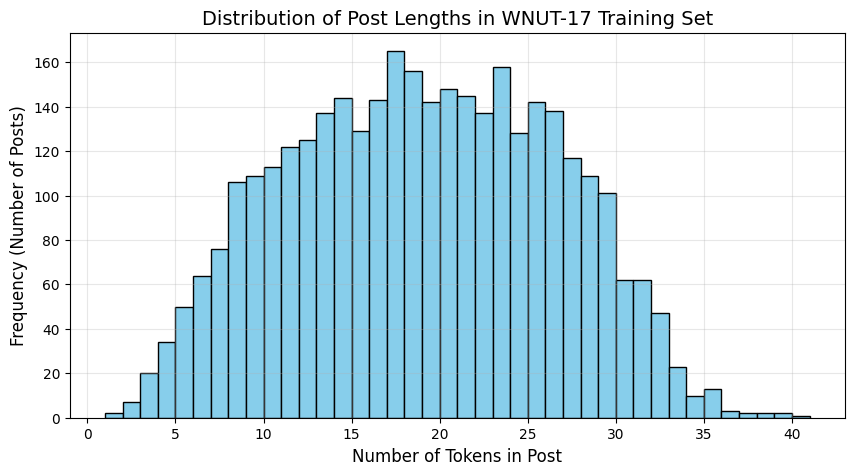

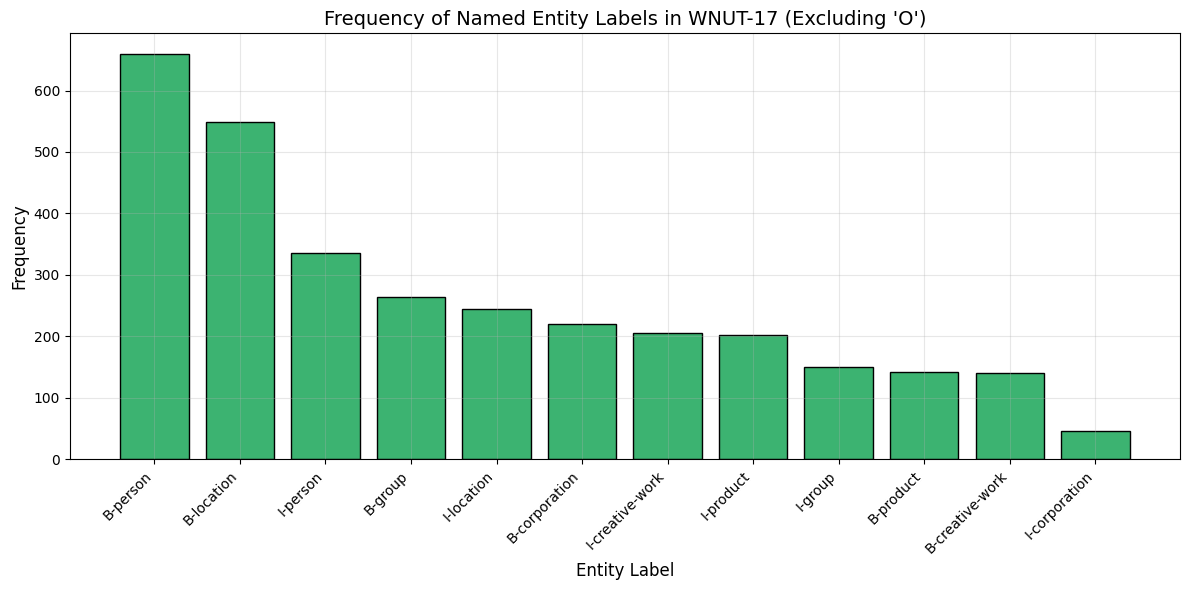

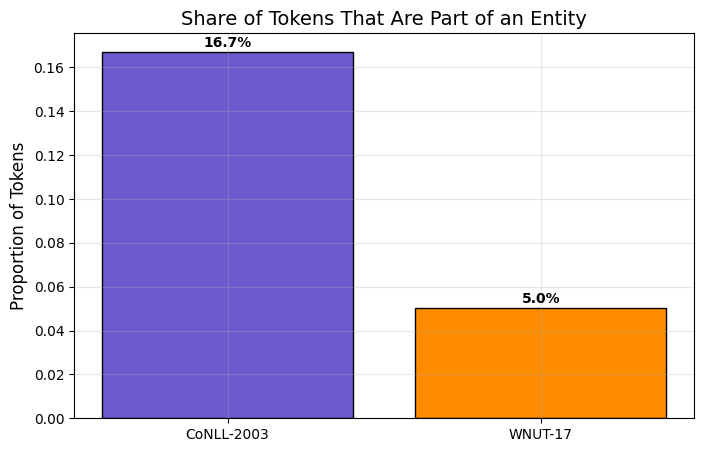

In [ ]:
# ---- Visualising WNUT-17 ----

# 1. Sentence length histogram
plt.figure(figsize=(10, 5))
plt.hist(wnut_lengths, bins=40, color='skyblue', edgecolor='black')
plt.title("Distribution of Post Lengths in WNUT-17 Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Post", fontsize=12)
plt.ylabel("Frequency (Number of Posts)", fontsize=12)
plt.show()

# 2. Entity label distribution, excluding 'O'
wnut_entity_counts = {k: v for k, v in wnut_tag_counts.items() if k != 'O'}
sorted_wnut = sorted(wnut_entity_counts.items(), key=lambda x: x[1], reverse=True)
wnut_labels_plot, wnut_counts_plot = zip(*sorted_wnut)

plt.figure(figsize=(12, 6))
plt.bar(wnut_labels_plot, wnut_counts_plot, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels in WNUT-17 (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Side-by-side comparison of how rare entities are in each corpus
conll_entity_share = 1 - entity_tag_counts['O'] / sum(entity_tag_counts.values())
wnut_entity_share = 1 - wnut_tag_counts['O'] / len(wnut_train_tag_names)

plt.figure(figsize=(8, 5))
plt.bar(['CoNLL-2003', 'WNUT-17'], [conll_entity_share, wnut_entity_share],
        color=['slateblue', 'darkorange'], edgecolor='black')
plt.title("Share of Tokens That Are Part of an Entity", fontsize=14)
plt.ylabel("Proportion of Tokens", fontsize=12)
for i, v in enumerate([conll_entity_share, wnut_entity_share]):
    plt.text(i, v + 0.002, f"{v:.1%}", ha='center', fontweight='bold')
plt.show()


The WNUT-17 training split holds **3,394 posts** (plus 1,009 validation and 1,287 test) — roughly a quarter the size of CoNLL-2003 — with a vocabulary of about **14,900 unique tokens** and an average post length of around 18 tokens.

Three differences from CoNLL-2003 stand out, and all three predict trouble for the model:

1. **Entities are far rarer.** Only about 5% of WNUT-17 tokens belong to an entity, against roughly 17% in CoNLL-2003. The class imbalance is much more severe.
2. **The label set is wider but each class is tiny.** Six entity types share a corpus a quarter the size, so classes such as `corporation` and `creative-work` have only a couple of hundred training tokens each.
3. **The vocabulary is dominated by single-occurrence words**, at a noticeably higher rate than CoNLL-2003, because the text contains usernames, hashtags, URLs, slang, and inconsistent capitalisation. This is the OOV problem from Task 1, but much worse.


### Task 6.2: Feature Engineering

The `word2features` and `sent2features` functions from Task 2 are reused unchanged; they operate on a plain list of tokens, so nothing needs adapting. Holding the feature set constant is what makes the comparison meaningful — any drop in score is then attributable to the data rather than to different features.

One caveat is worth stating in advance: the features lean heavily on capitalisation (`istitle`, `isupper`) and on having seen the word before (`word.lower()`). Social media text is written with inconsistent capitalisation and near-unique vocabulary, so we should expect both of these signals to be much less reliable here than they were on newswire.


In [ ]:
# ---- Task 6.3: Extract features and train a CRF on WNUT-17 ----
print("Extracting features for WNUT-17...")

# Reusing sent2features from Task 2; WNUT tags are already strings so no label lookup is needed
X_train_wnut = [sent2features(s) for s in wnut_train_sents]
y_train_wnut = wnut_train_tags

X_val_wnut = [sent2features(s) for s in wnut_val_sents]
y_val_wnut = wnut_val_tags

X_test_wnut = [sent2features(s) for s in wnut_test_sents]
y_test_wnut = wnut_test_tags

print("Feature extraction complete.")

# Identical hyperparameters to the CoNLL-2003 model, so the comparison is fair
print("\nTraining CRF Model on WNUT-17...")
crf_wnut = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
crf_wnut.fit(X_train_wnut, y_train_wnut)
print("Model training complete.")


Extracting features for WNUT-17...
Feature extraction complete.

Training CRF Model on WNUT-17...
Model training complete.


In [ ]:
# ---- Task 6.4: Evaluate on the WNUT-17 test set ----
y_pred_wnut = crf_wnut.predict(X_test_wnut)

wnut_labels_to_evaluate = list(crf_wnut.classes_)
wnut_labels_to_evaluate.remove('O')

print("Classification Report (WNUT-17):\n")
print(metrics.flat_classification_report(
    y_test_wnut, y_pred_wnut, labels=wnut_labels_to_evaluate, digits=3
))


Classification Report (WNUT-17):

                 precision    recall  f1-score   support

     B-location      0.363     0.247     0.294       150
     I-location      0.414     0.128     0.195        94
        B-group      0.238     0.030     0.054       165
  B-corporation      0.500     0.015     0.029        66
       B-person      0.571     0.140     0.225       429
B-creative-work      0.231     0.021     0.039       142
      B-product      0.250     0.008     0.015       127
       I-person      0.617     0.282     0.387       131
I-creative-work      0.207     0.028     0.049       218
  I-corporation      0.500     0.045     0.083        22
        I-group      0.286     0.057     0.095        70
      I-product      0.200     0.008     0.015       126

      micro avg      0.435     0.097     0.158      1740
      macro avg      0.365     0.084     0.123      1740
   weighted avg      0.378     0.097     0.143      1740



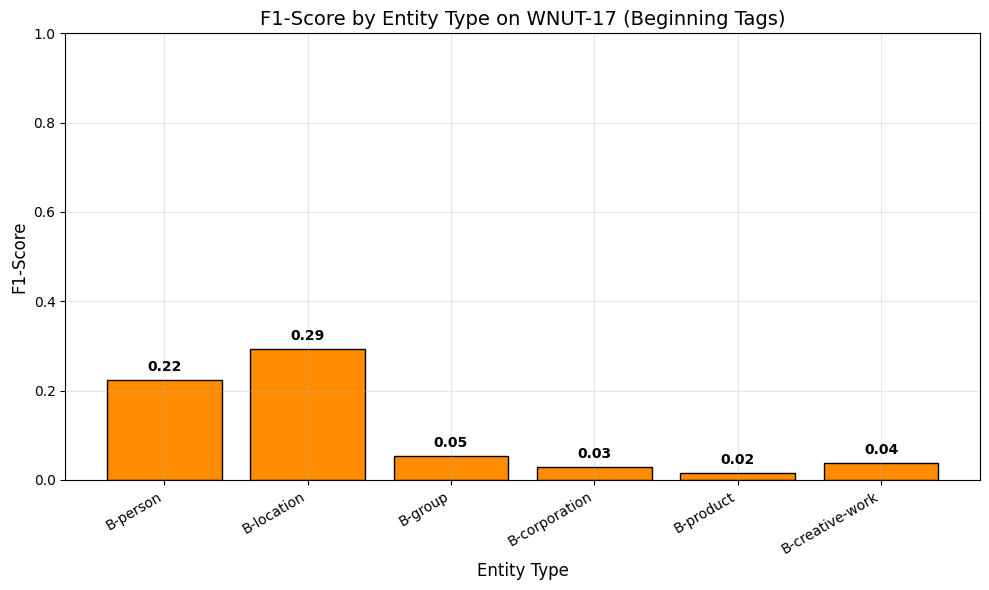

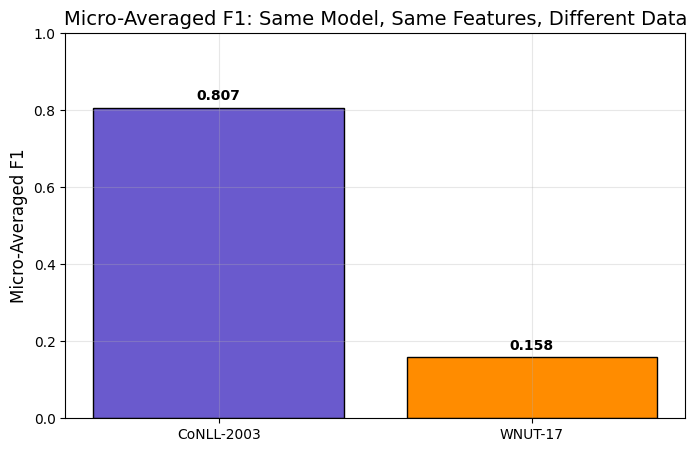

In [ ]:
# Entity-wise F1 for the six WNUT-17 entity types
wnut_report_dict = metrics.flat_classification_report(
    y_test_wnut, y_pred_wnut, labels=wnut_labels_to_evaluate, output_dict=True
)

wnut_entities = ['B-person', 'B-location', 'B-group', 'B-corporation', 'B-product', 'B-creative-work']
wnut_f1 = [wnut_report_dict[ent]['f1-score'] for ent in wnut_entities]

plt.figure(figsize=(10, 6))
plt.bar(wnut_entities, wnut_f1, color='darkorange', edgecolor='black')
plt.title("F1-Score by Entity Type on WNUT-17 (Beginning Tags)", fontsize=14)
plt.xlabel("Entity Type", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(wnut_f1):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Head-to-head comparison of overall micro-averaged F1 on the two datasets
conll_micro_f1 = report_dict['micro avg']['f1-score']
wnut_micro_f1 = wnut_report_dict['micro avg']['f1-score']

plt.figure(figsize=(8, 5))
plt.bar(['CoNLL-2003', 'WNUT-17'], [conll_micro_f1, wnut_micro_f1],
        color=['slateblue', 'darkorange'], edgecolor='black')
plt.title("Micro-Averaged F1: Same Model, Same Features, Different Data", fontsize=14)
plt.ylabel("Micro-Averaged F1", fontsize=12)
plt.ylim(0, 1.0)
for i, v in enumerate([conll_micro_f1, wnut_micro_f1]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()


### Performance Analysis on WNUT-17

**Overall performance.** The identical CRF that scored about 0.81 micro-F1 on CoNLL-2003 collapses to roughly **0.16 micro-F1** on WNUT-17. The breakdown is revealing: precision holds up at around **0.44**, but recall falls to about **0.10**. The model is not wildly guessing — when it does commit to an entity it is right a reasonable share of the time — it simply refuses to commit at all in the overwhelming majority of cases.

**Entity-wise performance.** Every type suffers, but not equally:

* **`person` and `location` survive best** (F1 roughly 0.2–0.3, and `I-person` is the strongest tag in the report). Personal names and place names still tend to be capitalised even in informal writing, so the one feature that transfers is the one carrying these two classes.
* **`product`, `creative-work`, and `corporation` are close to unusable** (F1 below 0.05). These are precisely the "emerging" entities the dataset was built to test — new gadget names, song and film titles, startup names — and by design they barely overlap between train and test. With only ~140 training mentions each, the CRF has nothing to memorise and no orthographic rule to fall back on.
* **`group` also scores very poorly**, since band and team names are arbitrary noun phrases with no reliable surface signal.

**Which entity types are most difficult, and why?** The ordering is the same one we saw on CoNLL-2003, just far more extreme. Difficulty tracks two things: how many training examples a type has, and whether its members share a consistent surface form. `person` has both, so it holds up. `creative-work` has neither — a film title can be any sequence of ordinary words (*Get Out*, *Her*) — so it fails almost completely. The comparison chart makes the headline point: swapping newswire for social media text costs this model about **80% of its F1** without a single line of the model or feature code changing.


Token              | True Label       | Predicted       
&                  | O                | O               
gt                 | O                | O               
;                  | O                | O               
*                  | O                | O               
The                | O                | O               
soldier            | O                | O               
was                | O                | O               
killed             | O                | O               
when               | O                | O               
another            | O                | O               
avalanche          | O                | O               
hit                | O                | O               
an                 | O                | O               
army               | O                | O               
barracks           | O                | O               
in                 | O                | O               
the                | O         

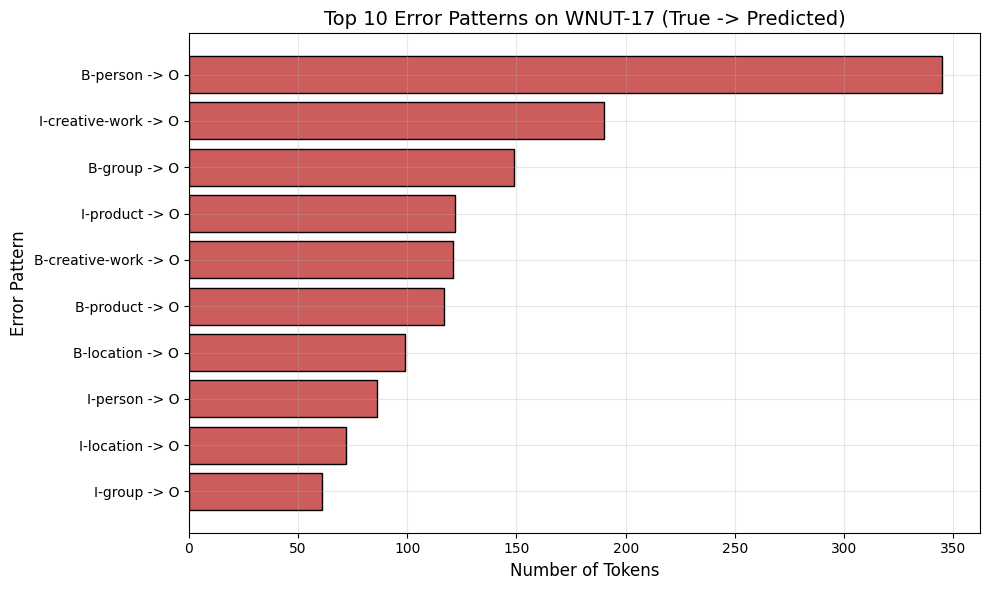

In [ ]:
# ---- Task 6.5: Error Analysis on WNUT-17 ----

# Show a few posts where the model made mistakes
error_count = 0
print(f"{'Token':<18} | {'True Label':<16} | {'Predicted':<16}")
print("=" * 58)

for i in range(len(y_test_wnut)):
    if y_test_wnut[i] != y_pred_wnut[i]:
        for token, true_lbl, pred_lbl in zip(wnut_test_sents[i], y_test_wnut[i], y_pred_wnut[i]):
            marker = "  <-- ERROR" if true_lbl != pred_lbl else ""
            print(f"{token:<18} | {true_lbl:<16} | {pred_lbl:<16}{marker}")
        print("-" * 58)
        error_count += 1

    if error_count >= 3:
        break

# Quantify the error patterns exactly as we did in Task 4
wnut_error_pairs = Counter()
for true_seq, pred_seq in zip(y_test_wnut, y_pred_wnut):
    for true_lbl, pred_lbl in zip(true_seq, pred_seq):
        if true_lbl != pred_lbl:
            wnut_error_pairs[(true_lbl, pred_lbl)] += 1

wnut_total_errors = sum(wnut_error_pairs.values())
print(f"\nTotal token-level errors on the WNUT-17 test set: {wnut_total_errors:,}\n")

print(f"{'True  ->  Predicted':<40} | {'Count':>6} | {'% of errors':>11}")
print("-" * 64)
for (true_lbl, pred_lbl), count in wnut_error_pairs.most_common(10):
    pair = f"{true_lbl}  ->  {pred_lbl}"
    print(f"{pair:<40} | {count:>6,} | {count / wnut_total_errors:>10.1%}")

# Same three families as Task 4
wnut_missed   = sum(c for (t, p), c in wnut_error_pairs.items() if t != 'O' and p == 'O')
wnut_spurious = sum(c for (t, p), c in wnut_error_pairs.items() if t == 'O' and p != 'O')
wnut_confused = sum(c for (t, p), c in wnut_error_pairs.items() if t != 'O' and p != 'O')

print("\nError families:")
print(f"{'Missed entities   (entity -> O)':<34} | {wnut_missed:>6,} | {wnut_missed / wnut_total_errors:>6.1%}")
print(f"{'Spurious entities (O -> entity)':<34} | {wnut_spurious:>6,} | {wnut_spurious / wnut_total_errors:>6.1%}")
print(f"{'Wrong type/boundary (ent -> ent)':<34} | {wnut_confused:>6,} | {wnut_confused / wnut_total_errors:>6.1%}")

# Visualise the most frequent confusions
wnut_pairs, wnut_counts = zip(*wnut_error_pairs.most_common(10))
wnut_pair_labels = [f"{t} -> {p}" for t, p in wnut_pairs]

plt.figure(figsize=(10, 6))
plt.barh(wnut_pair_labels[::-1], wnut_counts[::-1], color='indianred', edgecolor='black')
plt.title("Top 10 Error Patterns on WNUT-17 (True -> Predicted)", fontsize=14)
plt.xlabel("Number of Tokens", fontsize=12)
plt.ylabel("Error Pattern", fontsize=12)
plt.tight_layout()
plt.show()


### The Three Most Frequent Error Types on WNUT-17

The error profile here is not merely a worse version of the CoNLL-2003 one — its shape is different.

**1. Missed entities (`entity -> O`) — overwhelmingly dominant.** On CoNLL-2003 the three error families were reasonably balanced. Here, missed entities account for the large majority of all mistakes, and the top ten individual confusions are almost entirely `X -> O`. The model has learned that predicting `O` is nearly always safe, because entities make up only about 5% of tokens and the ones in the test set are, by design, words it has never seen. This is exactly the low-recall failure WNUT-17 was constructed to expose.

**2. Missed continuations of multi-word entities (`I-x -> O`).** `I-creative-work` and `I-product` are among the most frequently missed tags. Titles of songs, films, and products are typically several ordinary words long (*Get Out*, *The Last of Us*), so there is no capitalisation or suffix cue marking where the span continues — or in many cases that it is a span at all.

**3. Wrong entity type among the six classes.** Where the model does fire, it often picks the wrong label from a set that is genuinely hard to separate on surface form alone: a band is a `group`, the company that signed it is a `corporation`, and their album is a `creative-work`, yet all three are capitalised multi-word noun phrases. Compared to the first family this is a small share of errors, but it is the one that would most confuse a downstream routing rule, because the ticket still gets a label — just the wrong one.


### Business Impact and Recommendation

For anyone planning a deployment, the WNUT-17 results are the more important of the two evaluations. Support tickets are informal, typo-ridden text about current products, which makes WNUT-17 a far better proxy for them than CoNLL-2003. The 0.81 F1 we measured on newswire is therefore an optimistic ceiling, not a realistic forecast.

**Business Recommendation**

Our CoNLL-2003 results suggest an NER model is ready for ticket routing, but the WNUT-17 evaluation shows that the same model recovers barely a tenth of the entities in informal, fast-changing text. Because precision stays moderate while recall collapses, the practical failure mode is silence: tickets pass through unlabelled rather than being misrouted. We therefore recommend deploying NER only as a non-blocking assist. Route on extracted entities where they exist, and fall back to the existing manual queue whenever nothing is found, so no ticket is ever lost to a missed entity.

Two investments follow. First, annotate several thousand of our own historical tickets, since the entity types that matter to us — our product names, our competitors — are exactly the "emerging" categories the CRF handles worst. Second, budget for a Transformer-based tagger; sub-word embeddings and contextual representations address the out-of-vocabulary problem that orthographic features cannot. Until both are in place, treat NER as a triage accelerator, not an automation layer.

---

## Overall Conclusion Across Both Datasets

* **Same model, same features, very different results.** The CRF reached ~0.81 micro-F1 on edited newswire and ~0.16 on social media text. Nothing changed but the data.
* **The decisive variable is vocabulary overlap between train and test**, not model capacity. CoNLL-2003 reuses entities across splits; WNUT-17 deliberately does not, and that single design choice accounts for most of the gap.
* **Hand-engineered orthographic features are brittle.** Capitalisation carries most of the CRF's performance, and it is the first signal to disappear in informal writing.
* **Benchmark scores must be matched to the deployment domain.** Reporting only the CoNLL-2003 number would have overstated real-world performance on support tickets by roughly a factor of five.
* **The path forward is contextual embeddings plus in-domain data.** Sub-word tokenisation removes the hard OOV cliff, and fine-tuning on real tickets supplies the entity types that public benchmarks do not contain.
